# Лекция 5

# Решение систем линейных уравнений. LU разложение. Число обусловленности

## На прошлой лекции

- Ранг матрицы
- Скелетное разложение
- Сингулярное разложение
- Задача малоранговой аппроксимации

## План на сегодня

- Линейные системы
- (P)LU разложение
- Устойчивость решения линейных систем и число обусловленности

## Линейные системы

$$ Ax = f, $$

где матрица $A$ и вектор $f$ известны.

Задача решения системы линейных уравнений – одна из основных задач вычислительной линейной алгебры.

Она возникает при решении следующих задач:

- задача линейной регрессии
- решение уравнений в частных производных и интегральных уравнений
- задачи нелинейной регрессии
- задачи оптимизации (методы Ньютона-Рафсона и Гаусса-Ньютона, условия ККТ)

## Пере- и недоопределённые линейные системы

Если система $Au = f$ имеет
- больше уравнений, чем неизвестных, она называется **переопределённой** (в общем случае не имеет решений)

- меньше уравнений, чем неизвестных, она называется **недоопределённой** (решение неединственно, нужны дополнительные предположения, чтобы гарантировать единственность решения)

## Существование решений 

Решение системы линейных уравнений с квадратной матрицей $A$

$$A u = f$$

существует тогда и только тогда, когда 
* $\det A \ne 0$

или

* матрица $A$ имеет полный ранг.

## Шкала размерностей линейных систем 

В различных приложениях размерности линейных систем могут быть различны 

- Малая: $n \leq 10^4$ (вся матрица помещается в память, **плотные матрицы**)
- Средняя: $n = 10^4 - 10^6$ (обычно **разреженные** или **структурированные** матрицы)
- Большая: $n = 10^8 - 10^9$ (обычно **разреженные** матрицы и параллельные вычисления)

## Линейные системы могут быть структурированы

- Хранение $N^2$ элементов матрицы невозможно уже для $N = 100000$.  

**Q:** как работать с такими матрицами?  

**A:** к счастью, такие матрицы чаще всего являются **структурированными** и требуют хранения $\mathcal{O}(N)$ элементов.

- Наиболее растространённый тип структурированных матриц – это разреженные матрицы: такие матрицы имеют только $\mathcal{O}(N)$ ненулевых элементов!  

- Пример (одна из самых известных матриц для $n = 5$):

$$
  \begin{pmatrix}
  2 & -1 & 0 & 0 & 0 \\
  -1 & 2 & -1 & 0 & 0 \\
  0 & -1 & 2 & -1 & 0 \\
  0 & 0 &-1& 2 & -1  \\
  0 & 0 & 0 & -1 & 2 \\
  \end{pmatrix}
$$

- По крайней мере можно хранить такие матрицы
- Также можно умножать такие матрицы на вектор быстро
- Но как решать линейные системы с такими матрицами?

## Основные вопросы о линейных системах

1. Какую точность мы можем получить от решения (из-за ошибок округления)?
2. Как мы вычислим решение? (LU разложение, метод Гаусса)
3. Какая сложность решения системы линейных уравнений?

## Как решать линейные системы?

**Важно**: забудьте о детерминантах и правиле Крамера (хотя они полезны для матриц $2 \times 2$)!

In [1]:
import numpy as np

def bad_cramer(A, b):
    det = np.linalg.det(A)
    x = np.empty_like(b)
    for i in range(b.shape[0]):
        cur_col = A[:, i].copy()
        A[:, i] = b.copy()
        cur_det = np.linalg.det(A)
        x[i] = cur_det / det
        A[:, i] = cur_col.copy()
    return x

n = 100
A = np.random.randn(n, n)
Q, _ = np.linalg.qr(A)
eigvals = np.arange(1, n+1, dtype=float)
eigvals[-1] = 10000
eigvals[0] = 0.0001
A = Q @ np.diag(eigvals) @ Q.T
b = np.random.randn(n)
# print(np.linalg.cond(A))

x_good = np.linalg.solve(A, b)
x_bad = bad_cramer(A, b)
print(np.linalg.norm(A @ x_bad - b) / np.linalg.norm(b))
print(np.linalg.norm(A @ x_good - b) / np.linalg.norm(b))
%timeit np.linalg.solve(A, b)
%timeit bad_cramer(A, b)

5.837630718813645e-08
2.1909500560608876e-10
36.3 μs ± 116 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
3.49 ms ± 7.33 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Как решать линейные системы?

Основной инструмент – исключение переменных. 

\begin{align*}
    &2 y + 3 x = 5 &\longrightarrow \quad &x = 5/3 -  2/3 y &\longrightarrow \quad & x = 5/3 -  2/3 y\\
    &2 x + 3z = 5 &\longrightarrow\quad &2(5/3 -  2/3 y) + 3z = 5 &\longrightarrow \quad & y = (-5 + 10/3 + 3z) \cdot 3/4\\
    &z + y = 2 &\longrightarrow\quad  & z + y = 2, &\longrightarrow \quad & (-5 + 10/3 + 3z) \cdot 3/4 + z = 2\\
\end{align*}

и так вы можете найти $z$ (и все остальные неизвестные).  

Этот процесс называется **методов Гаусса** и является одним из самых часто используемых алгоритмов. 

## Метод Гаусса

Метод Гаусса состоит из двух этапов:
1. Проход вниз
2. Проход вверх

## Проход вниз

- Исключим $x_1$:

$$
   x_1 = f_1 - (a_{12} x_2 + \ldots + a_{1n} x_n)/a_{11},
$$

и подставим в уравнения $2, \ldots, n$. 

- Затем исключим $x_2$ и подставим в остальные уравнения.

- Важно, что ведущий элемент (pivot), тот на который мы делим, не равен $0$.

## Проход вверх

Во время прохода назад:
- решаем уравнение для $x_n$
- подставляем решение в уравнение для $x_{n-1}$ и так далее, пока не вычислим все $x_i, i=1,\ldots, n$.

## Метод Гаусса и LU разложение

Метод Гаусса связан с вычислением одного из самых важных матричных разложений: **LU разложения**.

**Определение**: LU разложение матрицы $A$ – это представление

$$A =  LU,$$

где $L$ – **нижнетреугольная** и $U$ – **верхнетреугольная** матрица.

Это разложение **неединственно**, поэтому обычно требуют дополнительно, что на диагонали матрицы $L$ стоят 1.

## Обратная матрица: определение

Матрица, обратная к матрице $A$, это такая матрица $X$ что  

$$
   AX = XA = I, 
$$

где $I$ – единичная матрица. Обратная матрица обозначается как $A^{-1}$.

Вычисление обратной матрицы связано с решением линейной системы. В самом деле, $i$-ый столбец произведения даёт

$$
A x_i = e_i,
$$

где $e_i$ – $i$-ый столбец единичной матрицы. 
Таким образом, мы можем использовать метод Гаусса, чтобы решить эту систему.


## Решение системы линейных уравнений после вычисления LU разложения

**Основная цель** вычисления LU разложения – это решение системы линейных уравнений, поскольку

$$
    x^* = A^{-1} f = (L U)^{-1} f = U^{-1} L^{-1} f, 
$$

и задача сводится к решению двух линейных систем с верхне- и нижнетреугольными матрицами.

Проход вниз выражается в виде

$$
     L y = f, 
$$

аналогично для прохода вверх

$$
   U x = y.
$$

Всегда ли существует $LU$ разложение?

## Существование LU разложения

Алгоритм вычисления LU разложения работает, если **мы не делим на $0$** на каждом шаге метода Гаусса.

**Q:** Для какого класса матриц это так?

**A:** Это так для **строго регулярных матриц**.

## Строго регулярные матрицы и LU разложение

**Определение.** Матрица $A$ называется *строго регулярной*, если все лидирующие главные миноры (подматрицы из первых $k$ строк и $k$ столбцов) не вырождены. 

В этом случае LU разложение всегда существует. Обратное также верно (проверьте!).

## LU разложение для положительно определённых Эрмитовых матриц (разложение Холецкого)

Строго регулярные матрицы имеют LU разложение. 

Важный класс строго регулярных матриц – это класс **Эрмитовых положительно определённых матриц**

**Определение.** Матрица $A$ называется Эрмитовой положительно определённой, если для любого $x \in \mathbb{C}^n: \Vert x \Vert \ne 0$ выполнено

$$
(x, Ax) > 0.
$$

**Утверждение:** Эрмитова положительно определённая матрица $A$ строго регулярна и имеет разложение Холецкого вида

$$A = RR^*,$$

где $R$ нижнетреугольная матрица.

Часто матрица $R$ называется "квадратным корнем" матрицы $A$. 

## Вычисление LU разложения

- Во многих случаях достаточно один раз вычислить LU разложение!

- Если такое разложение найдено (что требует $\mathcal{O}(n^3)$ операций), тогда решение линейной системы сводится к решению линейных систем с матрицами $L$ и $U$, которые требуют $\mathcal{O}(n^2)$ операций.

**Упражнение:** Решение линейной системы с треугольной матрицей вычисляется быстро. Как вычислить $L$ и $U$?

## Два способа вычисления LU разложения

- Способ 1
    - Элементарными преобразованиями $E_i$ приводим матрицу $A$ к верхнетреугольному виду:
    
    $$ E_n \ldots E_1 A = U \quad A = (E_1 \ldots E_n)^{-1} U = LU$$
    
    - Так как $E_i$ – нижнетреугольные матрицы, то их произведение и обратная к их произведению матрица также нижнетреугольная, которую можно обозначить $L$

- Способ 2 (алгоритм Дулитла)
    - Распишем поэлементно равенство $A = LU$
    $$ a_{11} = u_{11} \quad a_{12} = u_{12} \quad a_{13} = u_{13}$$
    
    $$ l_{21} = \frac{a_{21}}{a_{11}} \quad l_{31} = \frac{a_{31}}{a_{11}}$$
    
    $$ u_{22} = \ldots \quad u_{23} = \ldots $$
    
    - Можно последовательно выразить строки $U$ и столбцы $L$

## Сложность метода Гаусса/LU разложения

- Каждый шаг исключения занимает $\mathcal{O}(n^2)$ операций. 

- Таким образом, сложность алгоритма $\mathcal{O}(n^3)$.  

In [143]:
def elementary_lu(A):
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)
    for i in range(n):
        el_transform = U[i+1:, i] / U[i, i]
        L[i+1:, i] = el_transform
        U[i+1:, i:] -= np.outer(L[i+1:, i], U[i, i:])
    return L, U

def doolittle(A):
    n = A.shape[0]
    U = np.zeros((n, n))
    L = np.eye(n)
    for i in range(n):
        U[i, i:] = A[i, i:] - L[i, :i] @ U[:i, i:]
        L[(i+1):, i] = (A[(i + 1):, i] - L[(i+1):] @ U[:, i]) / U[i, i]
    return L, U

n = 100
A = np.random.randn(n, n)
Q, _ = np.linalg.qr(A)
eigvals = np.arange(1, n+1, dtype=float)
eigvals[-1] = 100
eigvals[0] = 1
A = Q @ np.diag(eigvals) @ Q.T

L_e, U_e = elementary_lu(A)
L_d, U_d = doolittle(A)
print(np.linalg.norm(A - L_e @ U_e))
print(np.linalg.norm(A - L_d @ U_d))

%timeit elementary_lu(A)
%timeit doolittle(A)

1.6816004769691313e-13
2.9709118060706874e-14
1.96 ms ± 194 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
The slowest run took 10.52 times longer than the fastest. This could mean that an intermediate result is being cached.
4.19 ms ± 5.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Когда алгоритм вычисления LU разложения не работает

- Что случится, если матрица не является строго регулярной (или ведущий элемент в методе Гаусса очень мал)?   

- Классический пример матрицы $2 \times 2$ с "плохим" LU разложением:

$$
    A = \begin{pmatrix}
    \varepsilon & 1 \\
    1 & 1 
    \end{pmatrix}
$$

- Если $\varepsilon$ достаточно мал, мы можем столкнуться с неустойчивостью. В то время как вычисление разложения Холецкого всегда устойчиво.

Проверим это численно...

In [ ]:
import numpy as np
eps = 1.1e-16
A = np.array([[eps, 1],[1.0,  1]])

def doolittle(A):
    n = A.shape[0]
    U = np.zeros((n, n))
    L = np.eye(n)
    for i in range(n):
        U[i, i:] = A[i, i:] - L[i, :i] @ U[:i, i:]
        L[(i+1):, i] = (A[(i + 1):, i] - L[(i+1):] @ U[:, i]) / U[i, i]
    return L, U


L_d, U_d = doolittle(A)
print('L * U - A:\n', np.dot(L_d, U_d) - A)
L_d, U_d

## Выбор ведущего элемента (pivoting)

Мы можем переставить строки и столбцы матрицы $A$ так, чтобы элемент $A_{kk}$, на который мы делим, был максимальным.  

Простейшая, но эффективная стратегия – это выбор максимального элемента в строке: на каждом шаге выбираем элемент, который максимален по модулю и перемещаем его на диагональ.

Это даёт следующее разложение 

$$A = P L U,$$

где $P$ – это **матрица перестановки**.


- Почему это хорошая стратегия?

In [ ]:
import scipy.linalg as splin

lu, p = splin.lu_factor(A)
L = np.tril(lu)
U = np.triu(lu)
np_piv = [1, 0]
print(p, "\n", L, "\n", U )
print((L @ U)[np_piv, :] - A)
I_guess = splin.lu_solve((lu, p), A)
print(I_guess)

## Устойчивость линейных систем

- Существует фундаментальная проблема с решением систем линейных уравнений, которая не зависит от используемого алгоритма.

- Она проявляется, когда элементы матрицы представляются как числа с плавающей точкой или имеется некоторый шум в измерениях.

Проиллюстрируем эту проблему на следующем примере.

2.0050775958428586


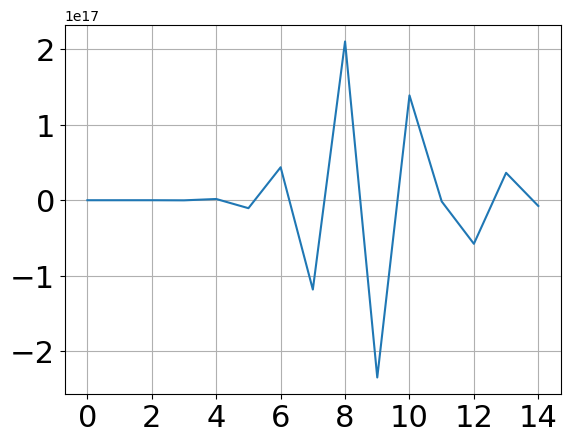

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
n = 15
a = [[1.0/(i + j + 1) for i in range(n)] for j in range(n)]
a = np.array(a)
rhs = np.random.randn(n) #Right-hand side
x = np.linalg.solve(a, rhs) #This function computes LU-factorization and solves linear system

#And check if everything is fine
er = np.linalg.norm(a.dot(x) - rhs) / np.linalg.norm(rhs)
print(er)
plt.plot(x)
plt.grid(True)
plt.xticks(fontsize=22)
_ = plt.yticks(fontsize=22)

## Ряд Неймана

Для того чтобы выяснить, почему в решении была такая большая ошибка, нам потребуется важный вспомогательный результат.  

**Ряд Неймана**:  

Если матрица $F$ такая что $\Vert F \Vert < 1$, тогда матрица $(I - F)$ обратима и

$$(I - F)^{-1} = I + F + F^2 + F^3 + \ldots = \sum_{k=0}^{\infty} F^k.$$

Заметим, что это матричная версия выражения для суммы геометрической прогрессии. 

## Доказательство

Сначала докажем, что ряд $\sum_{k=0}^{\infty} F^k$ сходится.  

Как и в скалярном случае выполнено

$$
   (I - F) \sum_{k=0}^N F^k = (I - F^{N+1}) \rightarrow I, \quad N \to +\infty
$$

Действительно,

$$
\| (I - F^{N+1}) - I\| = \|F^{N+1}\| \leqslant \|F\|^{N+1} \to 0, \quad N\to +\infty.
$$

Также можем оценить **норму обратной матрицы**:

$$
  \|(I - F)^{-1} \| = \left\Vert \sum_{k=0}^N F^k \right\Vert \leq \sum_{k=0}^N \Vert F \Vert^k \Vert I \Vert \leq \frac{\Vert I \Vert}{1 - \Vert F \Vert} 
$$

## Малое возмущение обратной матрицы

Используя этот результат, мы можем оценить как возмущение в элементах матрицы влияет на возмущение в элементах обратной матрицы. Предположим, что возмущение $E$ мало в том смысле, что $\Vert A^{-1} E \Vert < 1$. Тогда

$$(A + E)^{-1} = (A(I + A^{-1}E))^{-1} = (I + A^{-1}E)^{-1}A^{-1} = \sum_{k=0}^{\infty} (-A^{-1} E)^k A^{-1}$$

и

$$
  \frac{\Vert (A + E)^{-1} - A^{-1} \Vert}{\Vert A^{-1} \Vert} \leq \frac{\Vert A^{-1} E \Vert}{1 - \Vert A^{-1} E \Vert} \leq \frac{\Vert A^{-1} \Vert \Vert E \Vert}{1 - \Vert A^{-1} E \Vert}.
$$

Видно, что норма обратной матрицы входит в оценку.

## Число обусловленности линейной системы

Рассмотрим **возмущённую** линейную систему:

$$
   (A + \Delta A) (x + \Delta x) = f + \Delta f \quad \text{или} \quad (A + \Delta A)\Delta x = -\Delta A x + \Delta f
$$

такую что 

- $\| \Delta A \| \leq \epsilon \| A \|$ и $\| \Delta f \| \leq \epsilon \| f \|$
- Также $\epsilon \| A \| \| A^{-1} \| < 1$

## Оценки!

$$
\begin{split}
\Delta x &= (A + \Delta A)^{-1} (\Delta f - \Delta A x) =\\ 
&= \left(A(I + A^{-1}\Delta A)\right)^{-1}(\Delta f - \Delta A x) = \\
& = (I + A^{-1}\Delta A)^{-1} A^{-1} (\Delta f - \Delta A x) \\
\end{split}
$$

Далее оценим относительную ошибку
$$
\begin{split}
\frac{\| \Delta x \|}{\| x \|}& = \| (I + A^{-1}\Delta A)^{-1} \| \| A^{-1} \| \left( \frac{\| \Delta f \|}{\| x \|} + \frac{\| \Delta A x \|}{\| x \|} \right) \\
& = \| (I + A^{-1}\Delta A)^{-1} \| \| A^{-1} \| \left( \frac{\| \Delta f \|}{\| x \|} + \| \Delta A \| \right) \\
\end{split}
$$

Подробнее распишем первый множитель

$$\| (I + A^{-1}\Delta A)^{-1} \| \leq \sum_{k=0}^{\infty}\| A^{-1}\Delta A \|^k, $$

где $\| A^{-1}\Delta A \| \leq \| A^{-1}\| \| \Delta A \| \leq \epsilon \| A^{-1}\| \| A \| < 1$.

В этом случае

 $$ \| (I + A^{-1}\Delta A)^{-1} \| \leq \sum_{k=0}^{\infty}\| A^{-1}\|^k \|\Delta A \|^k = \frac{1}{1 - \| A^{-1}\| \|\Delta A \|}.$$
 
Тогда выражение для относительной ошибки примет вид

$$ \frac{\| \Delta x \|}{\| x \|} = \frac{1}{1 - \| A^{-1}\| \|\Delta A \|}\| A^{-1} \| \left( \frac{\| \Delta f \|}{\| x \|} + \| \Delta A \| \right) = \frac{\|A\| \|A^{-1}\}}{1 - \|A\| \|A^{-1}\| \frac{\|\Delta A \|}{\|A\|}} \left( \frac{\| \Delta f \|}{\|A\| \| x \|} + \frac{\| \Delta A \|}{\|A\|} \right) \leq \frac{\mathrm{cond}(A)}{1 - \mathrm{cond}(A) \frac{\|\Delta A \|}{\|A\|}} \left( \frac{\| \Delta f \|}{\|f\|} + \frac{\| \Delta A \|}{\|A\|} \right) $$

так как $ \|f \| = \|Ax\| \leq \|A\| \|x\|$

Главную роль играет **число обусловленности** матрицы $A$: $\mathrm{cond}(A) = \Vert A \Vert \Vert A^{-1} \Vert$.

## Число обусловленности

- Чем больше число обусловленности, тем меньше цифр в записи числа мы можем правильно восстановить. 
- Число обусловленности разное для разных норм.
- Для спектральной нормы выполнено (проверьте!) $\mathrm{cond}_2 (A) = \|A\|_2 \|A^{-1}\|_2 = \frac{\sigma_{\max}(A)}{\sigma_{\min}(A)}$
- Заметим, что если $\Delta A = 0$, тогда

$$
\frac{\Vert \widehat{x} - x \Vert}{\Vert x \Vert} \leq \mathrm{cond}(A) \frac{\|\Delta f\|}{\|f\|}
$$

## И снова матрица Гильберта 

- Проверим насколько оценка точная в двух случаях: единичная правая часть и случайная правая часть
- Результаты существенно отличаются!

Error: 3.027327541713639e-07 Condition number: 6.826635452329416e+21


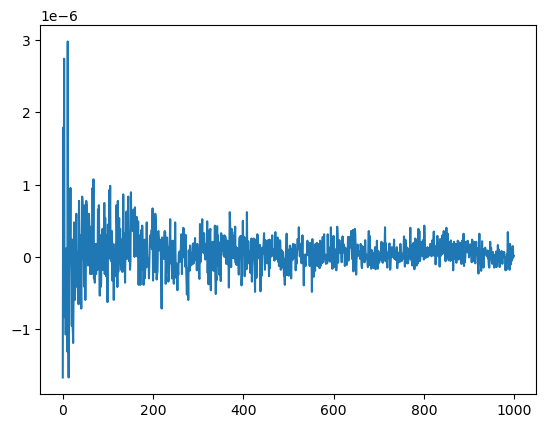

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


n = 1000
a = [[1.0/(i + j + 1) for i in range(n)] for j in range(n)]
a = np.array(a)
rhs = np.ones(n) #Right-hand side
f = np.linalg.solve(a, rhs)

#And check if everything is fine
er = np.linalg.norm(a.dot(f) - rhs) / np.linalg.norm(rhs)
cn = np.linalg.cond(a, 2)
print('Error:', er, 'Condition number:', cn)
plt.plot(a.dot(f) - rhs)

Error: 0.9612114432068972 Condition number: 2.907136039807352e+17


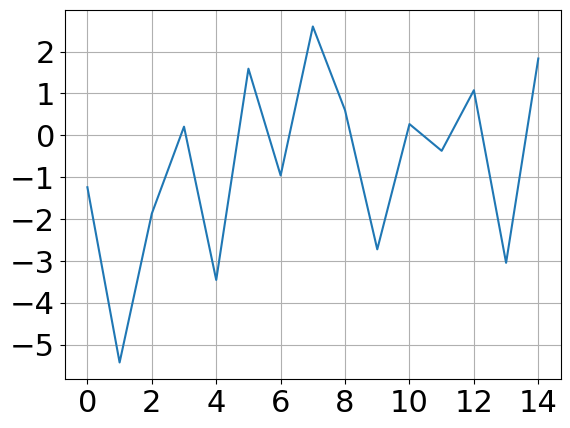

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

n = 15
a = [[1.0/(i + j + 1) for i in range(n)] for j in range(n)]
a = np.array(a)
rhs = np.random.randn(n) #Right-hand side
f = np.linalg.solve(a, rhs)

#And check if everything is fine
er = np.linalg.norm(a.dot(f) - rhs) / np.linalg.norm(rhs)
cn = np.linalg.cond(a)
print('Error:', er, 'Condition number:', cn)

u, s, v = np.linalg.svd(a)
rhs = np.random.randn(n)
plt.plot(a.dot(f) - rhs)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.grid(True)

## Промежуточный итог

- Что такое линейные системы и какими они бывают
- LU разложние и строго регулярные матрицы
- Разложение Холецкого как частный случай
- Способы вычисления и их сложность
- Перестановки расширяют область применения LU разложения
- Сложность в общем случае $O(n^3)$
- Ряд Неймана
- Для оценки устойчивости используется число обусловленности